# The IFT Correlated Field Model

By the end of this notebook you'll understand:
1. How a PSD encodes SFH burstiness.
2. How to read a PSD plot and predict the SFH character.
3. What σ_PS and τ_PS mean physically.

**The key equation** (Eq. 5 in the paper):

$$\ln \dot{M}_\star(t) = \ln \bar{\dot{M}}_\star(t) - K(0)/2 + x(t)$$

where $\bar{\dot{M}}_\star(t)$ is the smooth secular trend, $-K(0)/2$
is the lognormal correction ensuring the mean is preserved, and $x(t)$
is the stochastic fluctuation field drawn from a Gaussian process with
PSD $P(\omega)$.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri.models.sfh.psd_models import psd_drw
from tengri.models.sfh.gp_sfh import compute_sqrt_power_drw
from tengri.models.sfh.gp_sfh import gp_from_xi, generate_gp_fourier
from tengri.models.sfh.mean_sfh import tsnorm
from tengri.utils.grid import make_log_age_grid, grid_spacing

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("tutorials", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, setup_style  # noqa: E402

setup_style()

In [2]:
# Grid setup
N_GRID = 128
log_ages = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_ages)
ages_yr = 10**log_ages
ages_gyr = ages_yr / 1e9

## The Power Spectral Density

The PSD answers: how much variability power exists at each timescale?
It fully specifies the Gaussian process prior. We use a Damped Random
Walk (DRW, or Lorentzian): $P(\omega) = \sigma^2 \tau / (1 + (\omega\tau)^2)$.

In [3]:
# Four burstiness regimes
REGIMES = [
    {"sigma": 0.5, "tau_myr": 200, "label": "Smooth (σ=0.5, τ=200)", "color": COLORS["seq"][0]},
    {"sigma": 1.0, "tau_myr": 50,  "label": "Moderate (σ=1.0, τ=50)", "color": COLORS["seq"][2]},
    {"sigma": 2.0, "tau_myr": 20,  "label": "Bursty (σ=2.0, τ=20)", "color": COLORS["seq"][3]},
    {"sigma": 3.0, "tau_myr": 5,   "label": "Extreme (σ=3.0, τ=5)", "color": COLORS["seq"][4]},
]

W0325 11:54:56.944372 20176926 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


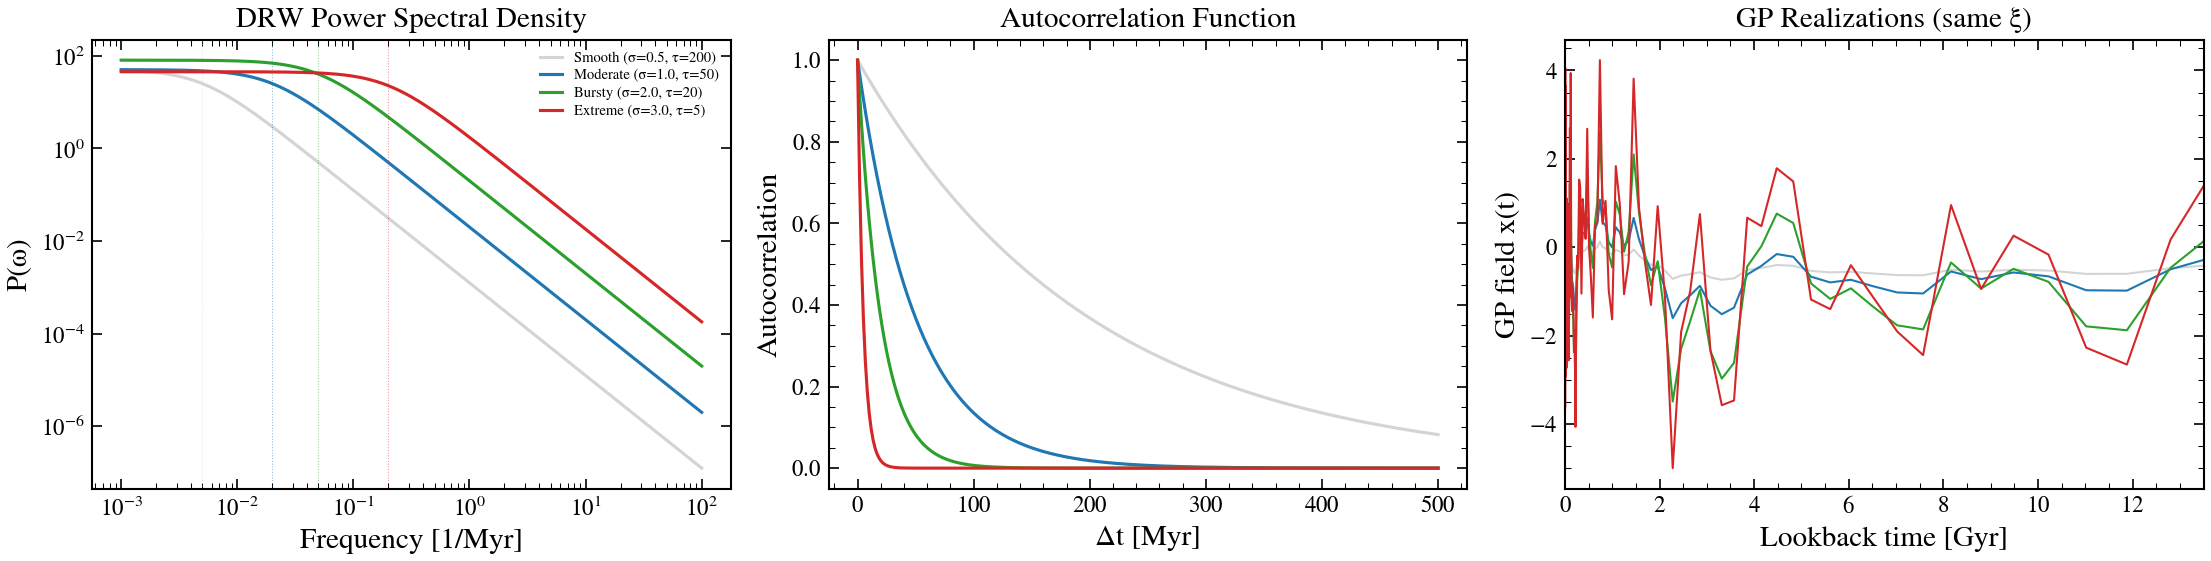

In [4]:
# --- FIGURE 1: DRW PSD for 4 regimes (3-panel) ---
omega = np.logspace(-3, 2, 500)  # frequency in 1/Myr

fig, (ax_psd, ax_acf, ax_gp) = plt.subplots(1, 3, figsize=(15, 4))

for reg in REGIMES:
    sigma, tau = reg["sigma"], reg["tau_myr"]
    # PSD
    P = sigma**2 * tau / (1 + (omega * tau)**2)
    ax_psd.loglog(omega, P, color=reg["color"], lw=1.5, label=reg["label"])
    # Break frequency
    ax_psd.axvline(1.0 / tau, color=reg["color"], ls=":", lw=0.5, alpha=0.5)

    # Autocorrelation
    dt = np.linspace(0, 500, 300)
    acf = np.exp(-dt / tau)
    ax_acf.plot(dt, acf, color=reg["color"], lw=1.5)

    # GP realization
    tau_yr = tau * 1e6
    sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_yr)
    xi = jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,))
    gp = gp_from_xi(xi, sqrt_power, N_GRID)
    ax_gp.plot(ages_gyr, np.array(gp), color=reg["color"], lw=1)

ax_psd.set_xlabel("Frequency [1/Myr]")
ax_psd.set_ylabel("P(ω)")
ax_psd.legend(fontsize=7)
ax_psd.set_title("DRW Power Spectral Density")

ax_acf.set_xlabel("Δt [Myr]")
ax_acf.set_ylabel("Autocorrelation")
ax_acf.set_title("Autocorrelation Function")

ax_gp.set_xlabel("Lookback time [Gyr]")
ax_gp.set_ylabel("GP field x(t)")
ax_gp.set_xlim(0, 13.5)
ax_gp.set_title("GP Realizations (same ξ)")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_psd_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

### What σ_PS and τ_PS Control

- **σ** controls amplitude — bigger σ means wilder swings in SFR.
- **τ** controls timescale — smaller τ means more rapid flickering.
Together they span the full range of SFH variability observed in galaxies.

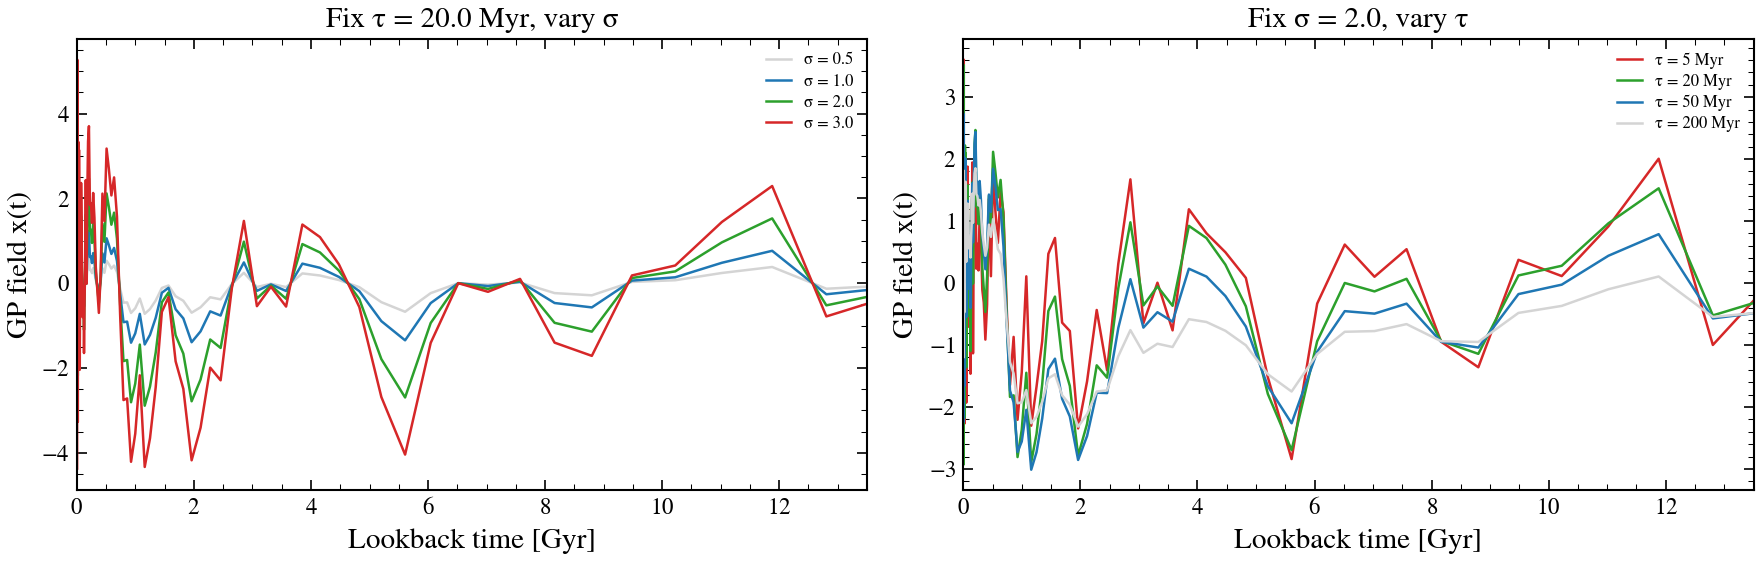

In [5]:
# --- FIGURE 2: Parameter sweeps ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(12, 4))

# Fix τ = 20 Myr, sweep σ
tau_fixed = 20.0  # Myr
xi = jax.random.normal(jax.random.PRNGKey(7), shape=(N_GRID,))
for sigma, c in [(0.5, COLORS["seq"][0]), (1.0, COLORS["seq"][2]),
                  (2.0, COLORS["seq"][3]), (3.0, COLORS["seq"][4])]:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_fixed * 1e6)
    gp = gp_from_xi(xi, sqrt_p, N_GRID)
    ax_sig.plot(ages_gyr, np.array(gp), color=c, lw=1.2, label=f"σ = {sigma}")
ax_sig.set_xlim(0, 13.5)
ax_sig.set_xlabel("Lookback time [Gyr]")
ax_sig.set_ylabel("GP field x(t)")
ax_sig.set_title(f"Fix τ = {tau_fixed} Myr, vary σ")
ax_sig.legend(fontsize=8)

# Fix σ = 2.0, sweep τ
sigma_fixed = 2.0
for tau, c in [(5, COLORS["seq"][4]), (20, COLORS["seq"][3]),
               (50, COLORS["seq"][2]), (200, COLORS["seq"][0])]:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma_fixed, tau * 1e6)
    gp = gp_from_xi(xi, sqrt_p, N_GRID)
    ax_tau.plot(ages_gyr, np.array(gp), color=c, lw=1.2, label=f"τ = {tau} Myr")
ax_tau.set_xlim(0, 13.5)
ax_tau.set_xlabel("Lookback time [Gyr]")
ax_tau.set_ylabel("GP field x(t)")
ax_tau.set_title(f"Fix σ = {sigma_fixed}, vary τ")
ax_tau.legend(fontsize=8)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_parameter_sweeps.png"), dpi=150, bbox_inches="tight")
plt.show()

## Building an SFH from Scratch

The magic of standardization: start with uncorrelated Gaussian noise
ξ ~ N(0, I), filter with √P to get correlated field x(t), combine with
mean SFH. Let's do it step by step.

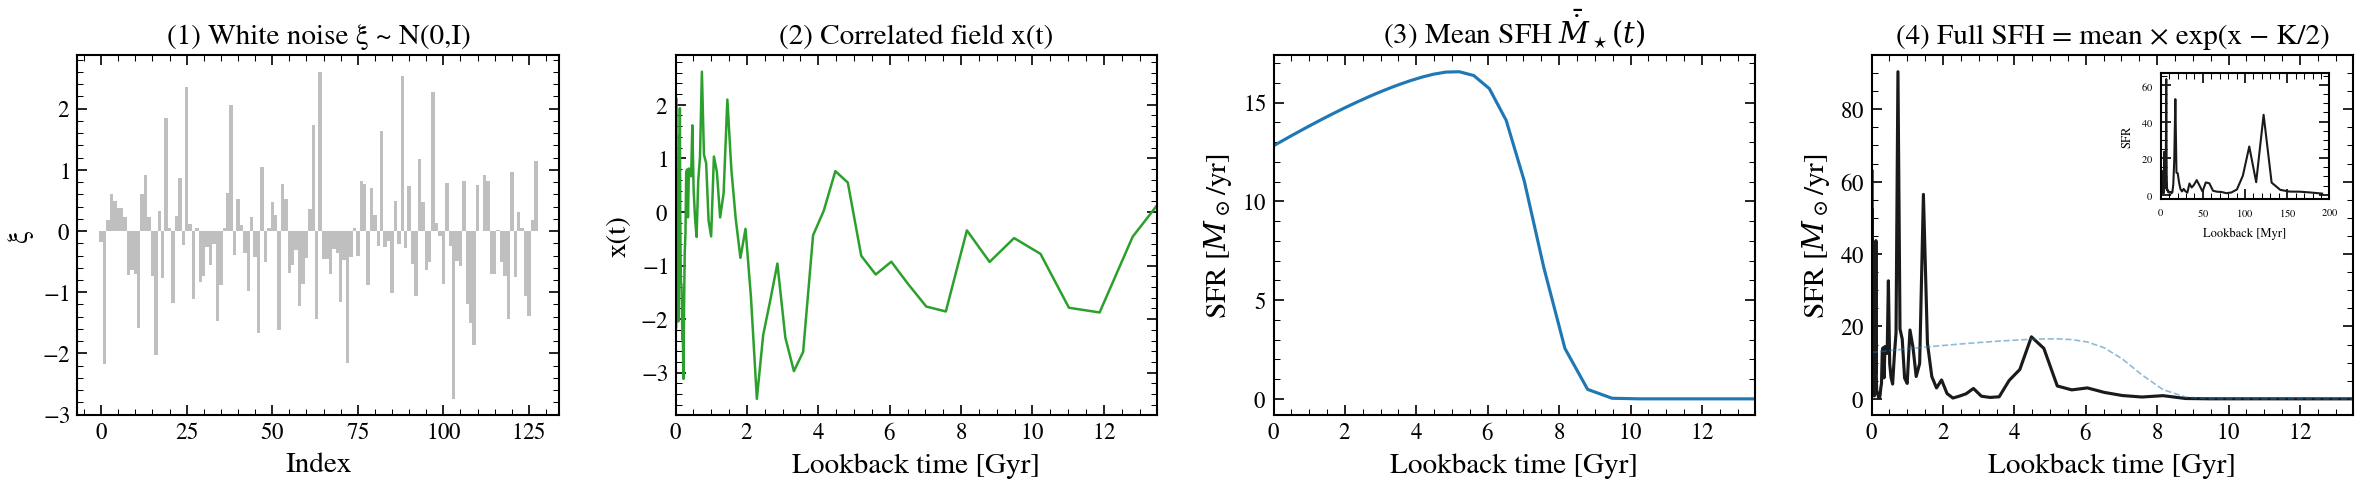

In [6]:
# --- FIGURE 3: Step-by-step assembly (1×4) ---
sigma, tau_myr = 2.0, 20.0
xi = jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,))
sqrt_power = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau_myr * 1e6)
gp = gp_from_xi(xi, sqrt_power, N_GRID)

# Mean SFH (tsnorm)
mean_sfr = tsnorm(
    ages_yr, log_peak_sfr=1.5, peak_lbt=6e9, width=2e9, skew=0.5, trunc=3.0
)

# Full SFH
gp_np = np.array(gp)
variance = float(jnp.var(gp))
sfr_full = np.array(mean_sfr) * np.exp(gp_np - variance / 2)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

# (1) White noise ξ
axes[0].bar(range(N_GRID), np.array(xi), width=1, color="grey", alpha=0.5)
axes[0].set_xlabel("Index")
axes[0].set_ylabel("ξ")
axes[0].set_title("(1) White noise ξ ~ N(0,I)")

# (2) Correlated field x(t)
axes[1].plot(ages_gyr, gp_np, color=COLORS["sfh_gp"], lw=1.2)
axes[1].set_xlabel("Lookback time [Gyr]")
axes[1].set_ylabel("x(t)")
axes[1].set_xlim(0, 13.5)
axes[1].set_title("(2) Correlated field x(t)")

# (3) Mean SFH
axes[2].plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=1.5)
axes[2].set_xlabel("Lookback time [Gyr]")
axes[2].set_ylabel(r"SFR [$M_\odot$/yr]")
axes[2].set_xlim(0, 13.5)
axes[2].set_title(r"(3) Mean SFH $\bar{\dot{M}}_\star(t)$")

# (4) Full SFH
axes[3].plot(ages_gyr, sfr_full, color=COLORS["truth"], lw=1.5)
axes[3].plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
axes[3].set_xlabel("Lookback time [Gyr]")
axes[3].set_ylabel(r"SFR [$M_\odot$/yr]")
axes[3].set_xlim(0, 13.5)
axes[3].set_title("(4) Full SFH = mean × exp(x − K/2)")
# 200 Myr inset
inset = axes[3].inset_axes([0.6, 0.6, 0.35, 0.35])
mask_200 = ages_gyr < 0.2
if hasattr(ages_gyr, "__len__") and np.any(mask_200):
    inset.plot(ages_gyr[mask_200] * 1e3, sfr_full[mask_200], color=COLORS["truth"], lw=1)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_step_by_step.png"), dpi=150, bbox_inches="tight")
plt.show()

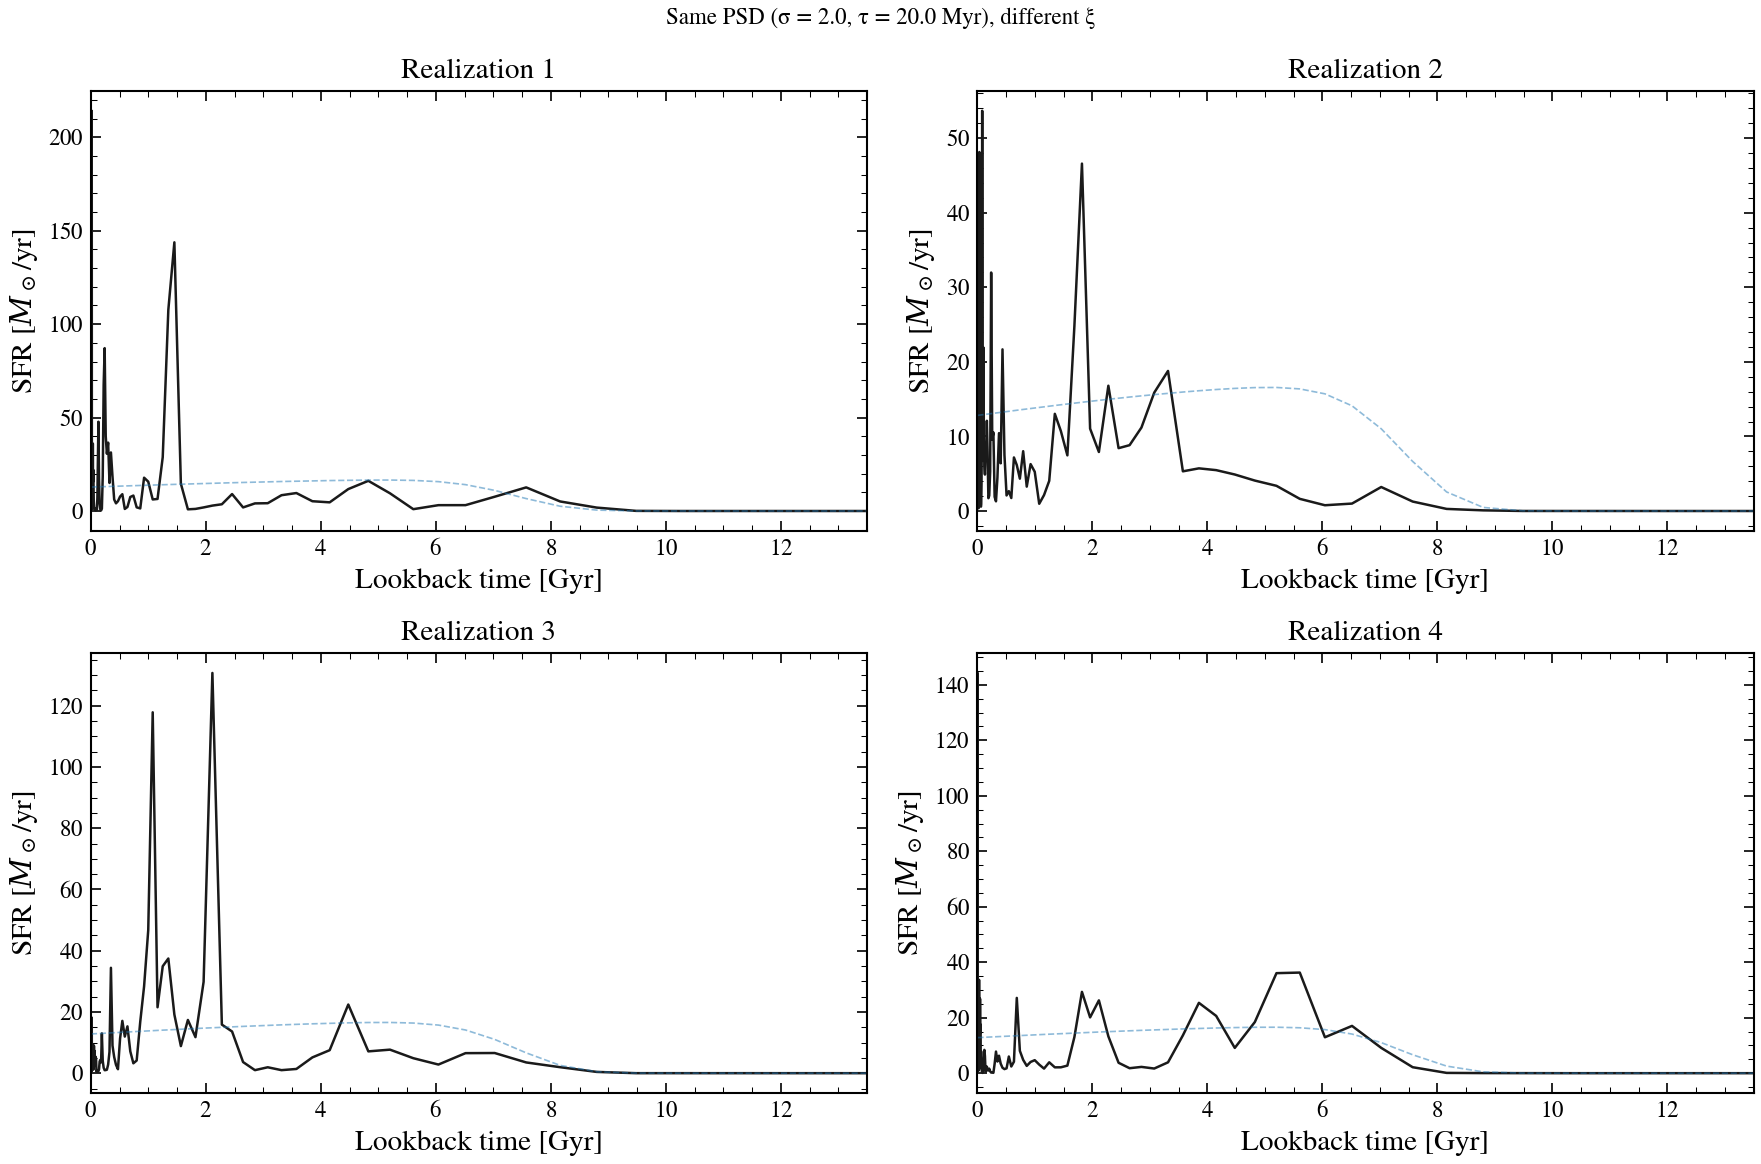

In [7]:
# --- FIGURE 4: Multiple realizations (2×2, same PSD) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, ax in enumerate(axes.flat):
    xi_i = jax.random.normal(jax.random.PRNGKey(idx * 7 + 3), shape=(N_GRID,))
    gp_i = np.array(gp_from_xi(xi_i, sqrt_power, N_GRID))
    sfr_i = np.array(mean_sfr) * np.exp(gp_i - variance / 2)
    ax.plot(ages_gyr, sfr_i, color=COLORS["truth"], lw=1.2)
    ax.plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 13.5)
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")
    ax.set_title(f"Realization {idx + 1}")
fig.suptitle(f"Same PSD (σ = {sigma}, τ = {tau_myr} Myr), different ξ", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_multiple_realizations.png"), dpi=150, bbox_inches="tight")
plt.show()

### The Lognormal Correction

The −K(0)/2 term ensures E[SFR] = mean SFR regardless of GP amplitude.
Without it, a zero-mean Gaussian in log-space would bias the linear-space
average upward.

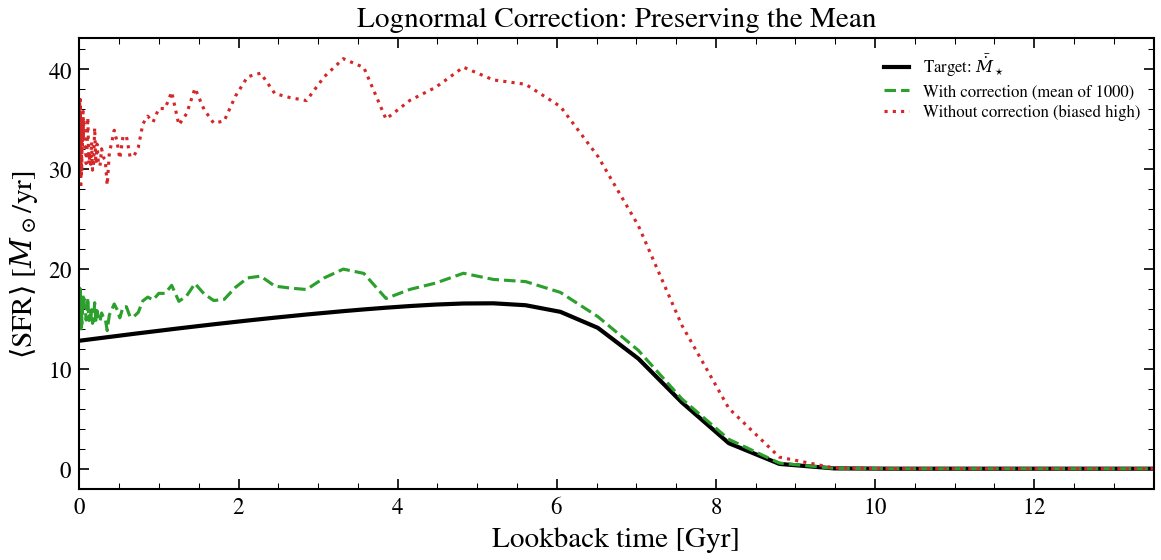

In [8]:
# --- FIGURE 5: With vs without correction ---
n_draws = 1000
sfr_with = []
sfr_without = []
for i in range(n_draws):
    xi_i = jax.random.normal(jax.random.PRNGKey(i), shape=(N_GRID,))
    gp_i = np.array(gp_from_xi(xi_i, sqrt_power, N_GRID))
    sfr_with.append(np.array(mean_sfr) * np.exp(gp_i - variance / 2))
    sfr_without.append(np.array(mean_sfr) * np.exp(gp_i))

mean_with = np.mean(sfr_with, axis=0)
mean_without = np.mean(sfr_without, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ages_gyr, np.array(mean_sfr), "k-", lw=2, label=r"Target: $\bar{\dot{M}}_\star$")
ax.plot(ages_gyr, mean_with, color=COLORS["sfh_gp"], lw=1.5, ls="--",
            label=f"With correction (mean of {n_draws})")
ax.plot(ages_gyr, mean_without, color=COLORS["model"], lw=1.5, ls=":",
            label=f"Without correction (biased high)")
ax.set_xlim(0, 13.5)
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"$\langle$SFR$\rangle$ [$M_\odot$/yr]")
ax.legend(fontsize=8)
ax.set_title("Lognormal Correction: Preserving the Mean")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_lognormal_correction.png"), dpi=150, bbox_inches="tight")
plt.show()

## The Secular Backbone

The GP has zero mean by construction, so we need a separate smooth secular
component. tengri supports 8 parametric shapes (plus tabulated). The
default is the truncated skew-normal (tsnorm, Bellstedt+2020).

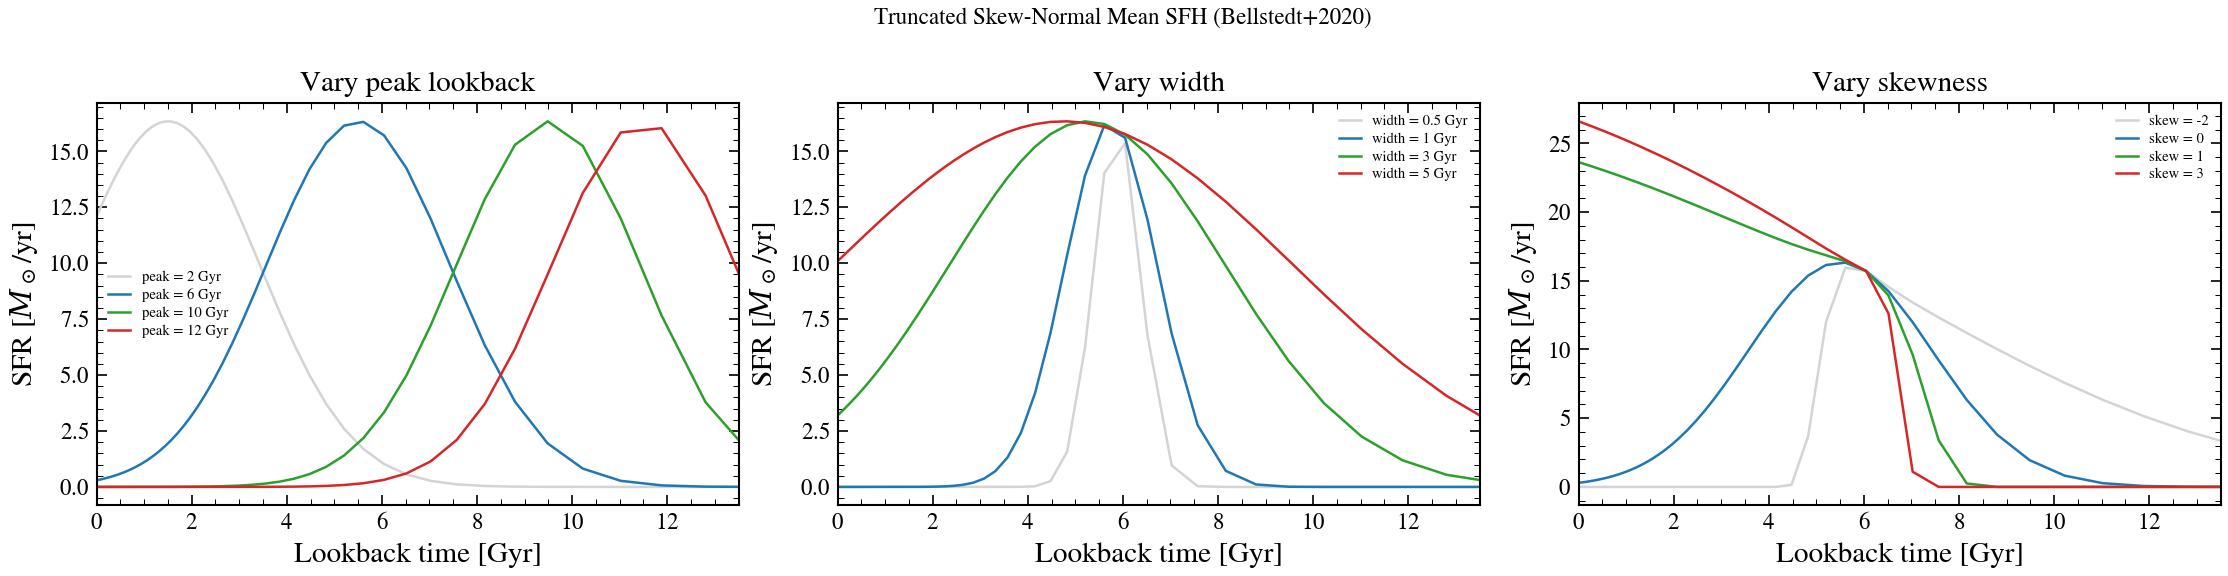

In [9]:
# --- FIGURE 6: tsnorm variations ---
fig, (ax_lbt, ax_w, ax_s) = plt.subplots(1, 3, figsize=(15, 4))

# Vary peak lookback
for lbt, c in [(2, COLORS["seq"][0]), (6, COLORS["seq"][2]),
               (10, COLORS["seq"][3]), (12, COLORS["seq"][4])]:
    sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=lbt * 1e9, width=2e9, skew=0.0, trunc=3.0)
    ax_lbt.plot(ages_gyr, np.array(sfr), color=c, lw=1.2, label=f"peak = {lbt} Gyr")
ax_lbt.set_xlim(0, 13.5)
ax_lbt.legend(fontsize=7)
ax_lbt.set_title("Vary peak lookback")

# Vary width
for w, c in [(0.5, COLORS["seq"][0]), (1, COLORS["seq"][2]),
             (3, COLORS["seq"][3]), (5, COLORS["seq"][4])]:
    sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=6e9, width=w * 1e9, skew=0.0, trunc=3.0)
    ax_w.plot(ages_gyr, np.array(sfr), color=c, lw=1.2, label=f"width = {w} Gyr")
ax_w.set_xlim(0, 13.5)
ax_w.legend(fontsize=7)
ax_w.set_title("Vary width")

# Vary skew
for s, c in [(-2, COLORS["seq"][0]), (0, COLORS["seq"][2]),
             (1, COLORS["seq"][3]), (3, COLORS["seq"][4])]:
    sfr = tsnorm(ages_yr, log_peak_sfr=1.5, peak_lbt=6e9, width=2e9, skew=float(s), trunc=3.0)
    ax_s.plot(ages_gyr, np.array(sfr), color=c, lw=1.2, label=f"skew = {s}")
ax_s.set_xlim(0, 13.5)
ax_s.legend(fontsize=7)
ax_s.set_title("Vary skewness")

for ax in [ax_lbt, ax_w, ax_s]:
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")

fig.suptitle("Truncated Skew-Normal Mean SFH (Bellstedt+2020)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig06_tsnorm_variations.png"), dpi=150, bbox_inches="tight")
plt.show()

## The Burstiness Plane

The (σ, τ) parameter space spans the full range of SFH variability.

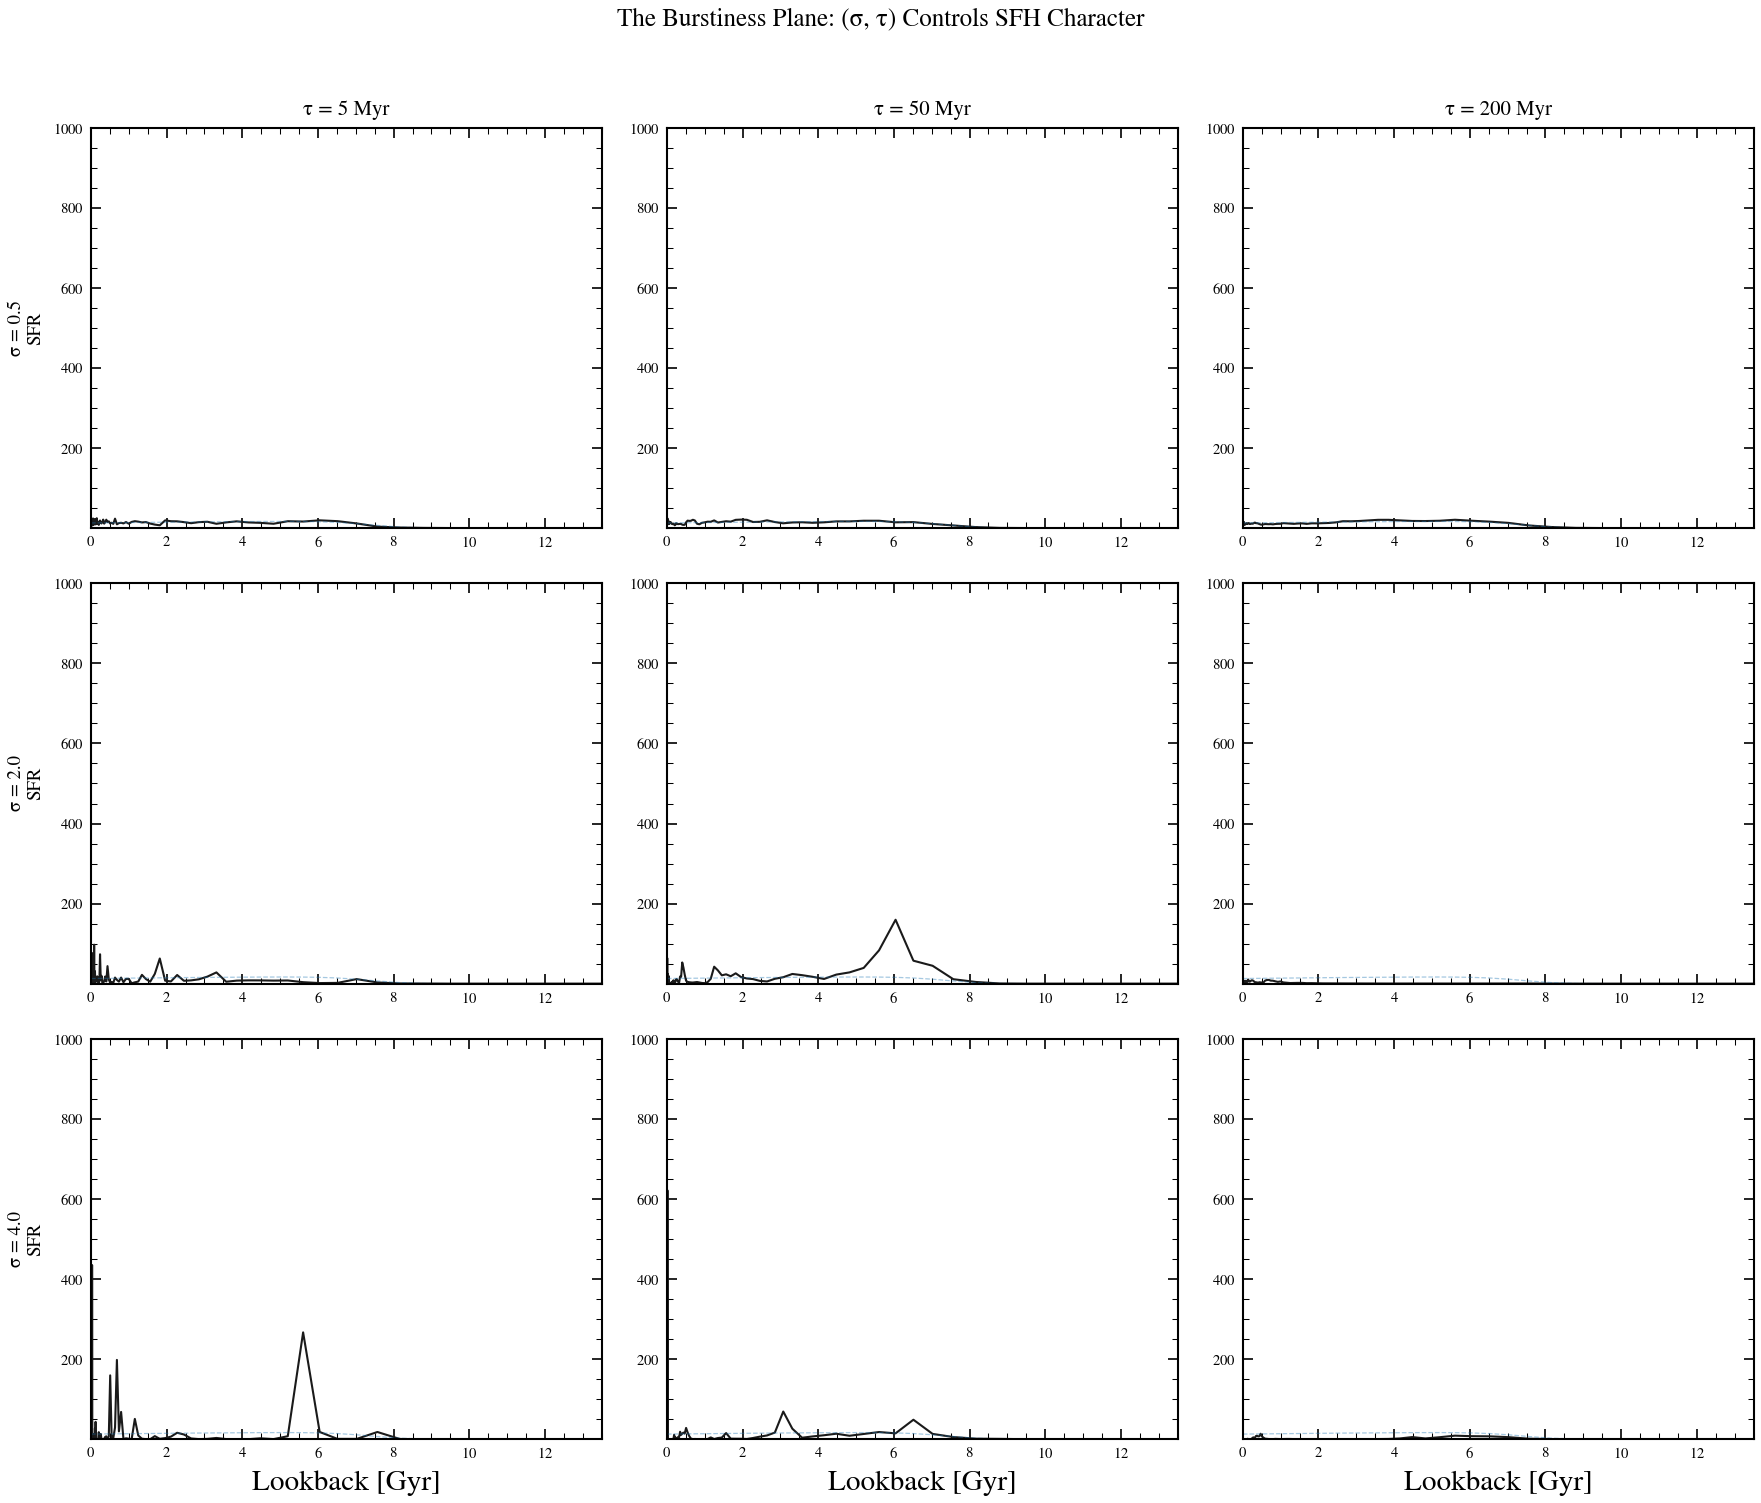

In [10]:
# --- FIGURE 7: 3×3 burstiness plane ---
sigmas = [0.5, 2.0, 4.0]
taus = [5, 50, 200]  # Myr

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, sigma in enumerate(sigmas):
    for j, tau in enumerate(taus):
        ax = axes[i, j]
        sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, tau * 1e6)
        xi_ij = jax.random.normal(jax.random.PRNGKey(i * 10 + j), shape=(N_GRID,))
        gp_ij = np.array(gp_from_xi(xi_ij, sqrt_p, N_GRID))
        var_ij = float(jnp.var(gp_from_xi(
            jax.random.normal(jax.random.PRNGKey(999), shape=(N_GRID,)), sqrt_p, N_GRID
        )))
        sfr_ij = np.array(mean_sfr) * np.exp(gp_ij - var_ij / 2)

        ax.plot(ages_gyr, sfr_ij, color=COLORS["truth"], lw=1)
        ax.plot(ages_gyr, np.array(mean_sfr), color=COLORS["sfh_mean"],
                    lw=0.6, ls="--", alpha=0.4)
        ax.set_xlim(0, 13.5)
        ax.set_ylim(1e-2, 1e3)

        if i == 0:
            ax.set_title(f"τ = {tau} Myr", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"σ = {sigma}\nSFR", fontsize=9)
        if i == 2:
            ax.set_xlabel("Lookback [Gyr]")
        ax.tick_params(labelsize=7)

fig.suptitle("The Burstiness Plane: (σ, τ) Controls SFH Character", fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig07_burstiness_plane.png"), dpi=150, bbox_inches="tight")
plt.show()

## Observable Connection

Different spectral tracers average over different lookback timescales:
Hα ~ few Myr, UV ~ 10–100 Myr, Balmer break ~ 100 Myr – 1 Gyr. The PSD
language makes this precise.

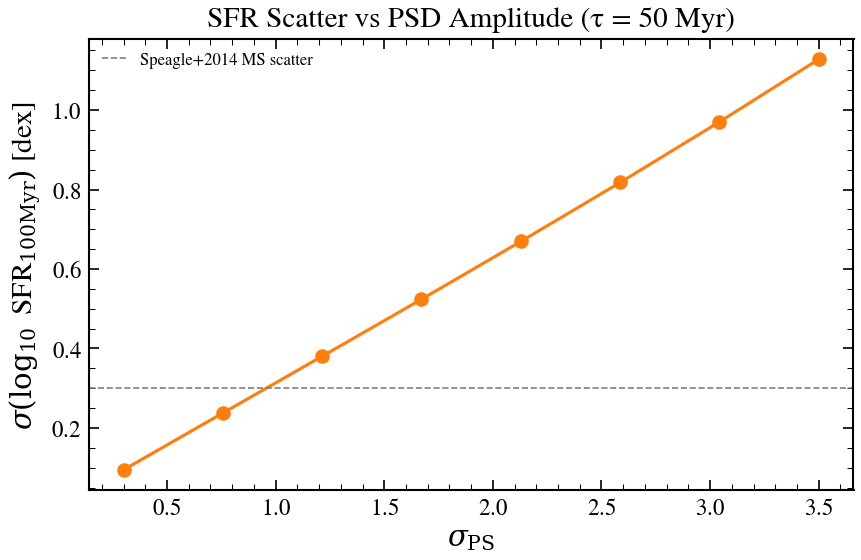

In [11]:
# --- FIGURE 8: Observable diagnostics ---
n_ens = 200
sig_range = np.linspace(0.3, 3.5, 8)

sfr_scatter_100 = []
for sigma in sig_range:
    sqrt_p = compute_sqrt_power_drw(N_GRID, d_log_age, sigma, 50.0 * 1e6)
    sfrs_100 = []
    for k in range(n_ens):
        xi_k = jax.random.normal(jax.random.PRNGKey(k + 1000), shape=(N_GRID,))
        gp_k = np.array(gp_from_xi(xi_k, sqrt_p, N_GRID))
        sfr_k = np.array(mean_sfr) * np.exp(gp_k - float(jnp.var(gp_from_xi(xi_k, sqrt_p, N_GRID))) / 2)
        # SFR at 100 Myr lookback
        idx_100 = np.argmin(np.abs(ages_gyr - 0.1))
        sfrs_100.append(sfr_k[idx_100])
    sfr_scatter_100.append(np.std(np.log10(np.clip(sfrs_100, 1e-5, None))))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sig_range, sfr_scatter_100, "o-", color=COLORS["geovi"], lw=1.5)
ax.axhline(0.3, color="grey", ls="--", lw=0.8, label="Speagle+2014 MS scatter")
ax.set_xlabel(r"$\sigma_{\rm PS}$")
ax.set_ylabel(r"$\sigma(\log_{10}$ SFR$_{100\rm Myr})$ [dex]")
ax.legend(fontsize=8)
ax.set_title("SFR Scatter vs PSD Amplitude (τ = 50 Myr)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig08_observable_diagnostics.png"), dpi=150, bbox_inches="tight")
plt.show()

## Physical Interpretation

| σ_PS | τ_PS | Physical regime |
|------|------|----------------|
| 0.3–0.5 | 100–300 Myr | Secular evolution (disk galaxies) |
| 0.5–1.5 | 20–100 Myr | Gas cycling, minor mergers |
| 1.5–2.5 | 5–50 Myr | SN feedback, dwarf starbursts |
| > 2.5 | < 10 Myr | Extreme dwarf, first galaxies |

These connect to simulations (Tacchella+2020, FIRE) and observed main-sequence
scatter (Caplar & Tacchella 2019, Iyer+2024).

## Summary

The PSD is a two-parameter prior that encodes physically motivated burstiness.
The framework accepts any PSD — DRW is just the default. The standardization
trick (ξ ~ N(0,I)) makes all inference methods work identically.

Next: **tutorials/04** shows how an SFH becomes an observable spectrum
through the differentiable forward model.